# Random Forest
Train and evaluate a random forest model using the prepared churn data.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

In [52]:
data = pd.read_csv('DataSet/ChurnData_prepared.csv')
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=9,class_weight='balanced_subsample', random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1081
           1       0.48      0.75      0.59       321

    accuracy                           0.76      1402
   macro avg       0.70      0.76      0.71      1402
weighted avg       0.81      0.76      0.78      1402



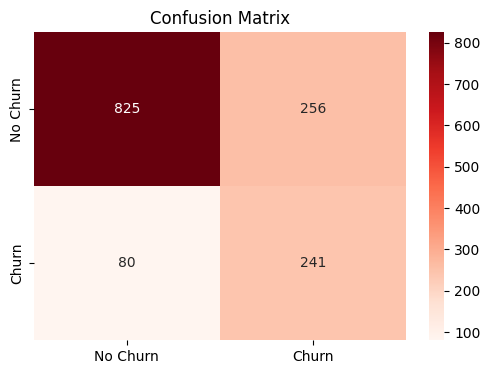

In [54]:
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.show()

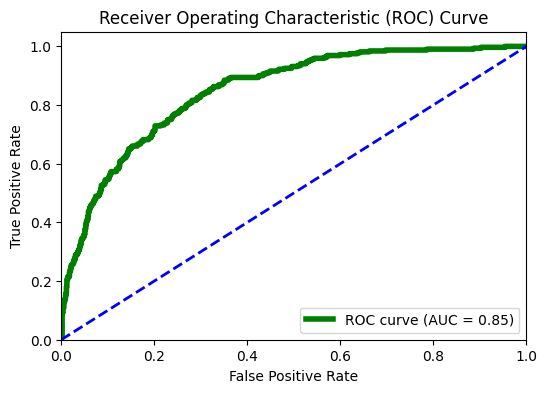

In [55]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='green', lw=4, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Optimal Threshold: 0.53
Best Class 1 F1-Score: 0.60
              precision    recall  f1-score   support

           0       0.91      0.79      0.85      1081
           1       0.51      0.73      0.60       321

    accuracy                           0.78      1402
   macro avg       0.71      0.76      0.72      1402
weighted avg       0.82      0.78      0.79      1402



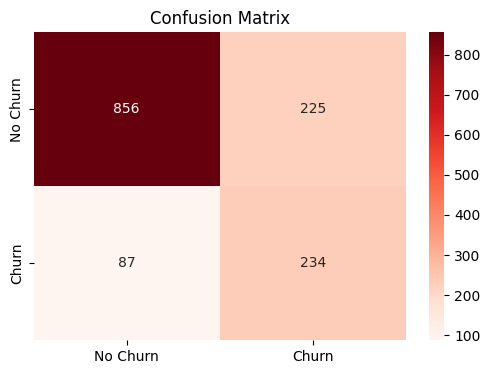

In [56]:
import numpy as np
from sklearn.metrics import f1_score


y_probs = rf_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0


for threshold in np.arange(0.40, 0.60, 0.01):
    preds = (y_probs >= threshold).astype(int)
    score = f1_score(y_test, preds, pos_label=1)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Best Class 1 F1-Score: {best_f1:.2f}")

# 3. Apply your optimal threshold
final_preds = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Reds', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.show()
